In [11]:
import scipy as sp
import scGAA
import scanpy as sc
import omicverse as ov
import numpy as np
import pandas as pd
import warnings 
import os
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.colors as colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
warnings.filterwarnings ("ignore")

In [3]:
train_adata = sc.read('data/train_adata.h5ad')
test_adata = sc.read('data/test_adata.h5ad')

axi

In [4]:
scGAA.train(train_adata, None, label_name='celltype', epochs=6, project='Demo_test')

cpu
Model builded!


[valid epoch 0] loss: 0.133, acc: 0.970: 100%|██████████| 1281/1281 [00:51<00:00, 24.95it/s]


Epoch: 0, Train Loss: 0.7448623468342255, Train Acc: 0.7548511207761793, Val Loss: 0.13326005541096433, Val Acc: 0.9699453551912568, Learning Rate: 0.0009336825748732972


[valid epoch 1] loss: 0.058, acc: 0.987: 100%|██████████| 1281/1281 [00:41<00:00, 31.03it/s]


Epoch: 1, Train Loss: 0.14319913576342422, Train Acc: 0.9668785547005687, Val Loss: 0.05840848852748707, Val Acc: 0.9869242779078845, Learning Rate: 0.0007524999999999999


...

Epoch: 3, Train Loss: 0.06552736621191765, Train Acc: 0.9852793576446972, Val Loss: 0.03960139373612534, Val Acc: 0.9899492583918813, Learning Rate: 0.00025750000000000013


[valid epoch 4] loss: 0.032, acc: 0.992: 100%|██████████| 1281/1281 [00:44<00:00, 28.95it/s]


Epoch: 4, Train Loss: 0.051396058211162284, Train Acc: 0.9887922382067581, Val Loss: 0.03228389611940287, Val Acc: 0.9922911787665886, Learning Rate: 7.631742512670284e-05


[valid epoch 5] loss: 0.030, acc: 0.992: 100%|██████████| 1281/1281 [00:45<00:00, 28.46it/s]


Epoch: 5, Train Loss: 0.04388015762385256, Train Acc: 0.9915105386416861, Val Loss: 0.030341059783768783, Val Acc: 0.9919008587041374, Learning Rate: 1e-05
Training finished!


In [39]:
model_weight_path = 'Demo_test/model-5.pth'
new_adata = scGAA.pre(test_adata, model_weight_path = model_weight_path,project='Demo_test')

cpu
0
2192


In [40]:
from sklearn import metrics
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(new_adata.obs['celltype'].values, new_adata.obs['Prediction'].values)

print("Accuracy: ", accuracy)
from sklearn.metrics import f1_score
f1 = f1_score(new_adata.obs['celltype'].values, new_adata.obs['Prediction'].values, average='macro')  
print(f"F1 Score: {f1}")

Accuracy:  0.9630474452554745
F1 Score: 0.918271856274778


In [8]:
test_adata.obs['Prediction'] = new_adata.obs['Prediction']

In [9]:
sc.pp.scale(test_adata, max_value=10) 
sc.tl.pca(test_adata, svd_solver='arpack')
sc.pp.neighbors(test_adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(test_adata)
sc.tl.tsne(test_adata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<AxesSubplot: title={'center': 'celltype'}, xlabel='X_umap1', ylabel='X_umap2'>

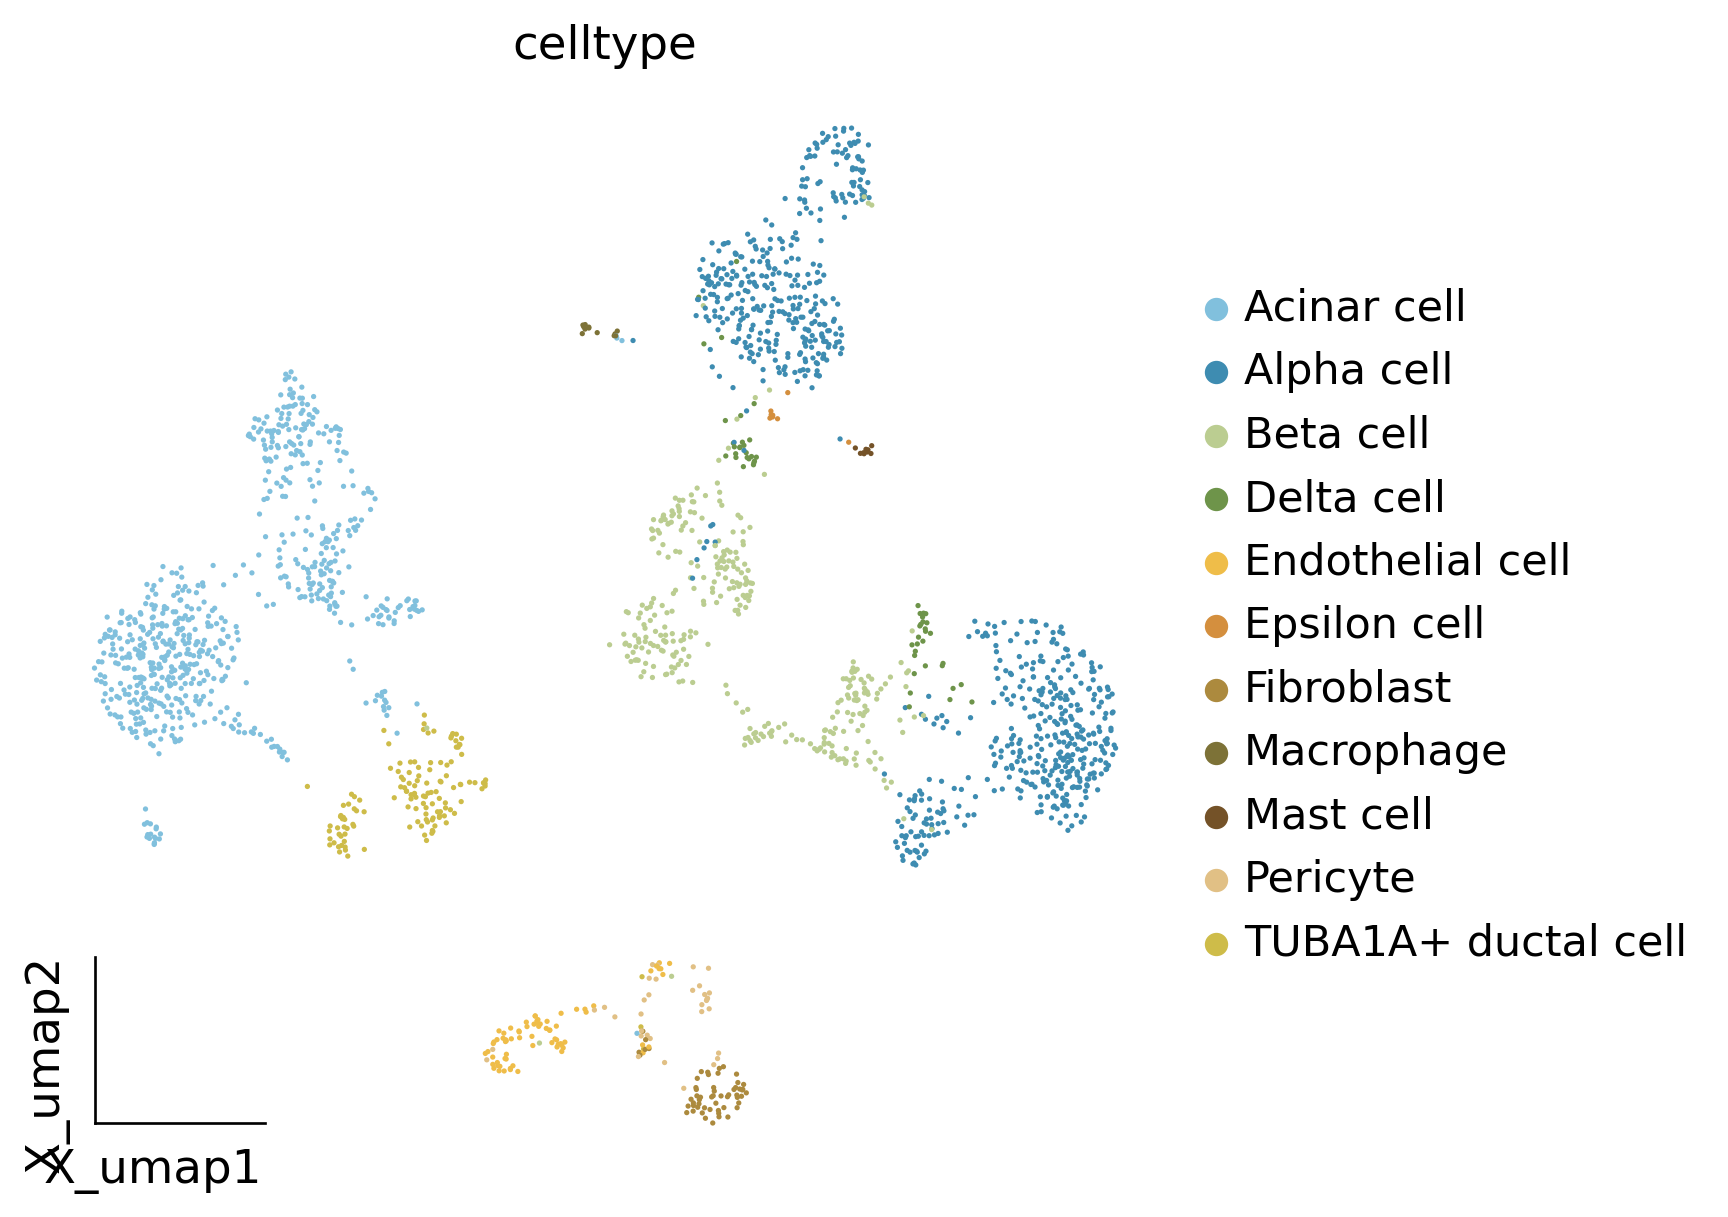

In [12]:
fig, ax = plt.subplots(figsize=(6,6))
ov.utils.embedding(test_adata,
    basis="X_umap",
    color=['celltype'],title='celltype',
    show=False,  
    size=10,
    frameon='small',
    palette=ov.utils.blue_color[2:4]+ov.utils.green_color[4:6]+ov.utils.orange_color[:],
    ax=ax
)

<AxesSubplot: title={'center': 'scGAA Prediction'}, xlabel='X_umap1', ylabel='X_umap2'>

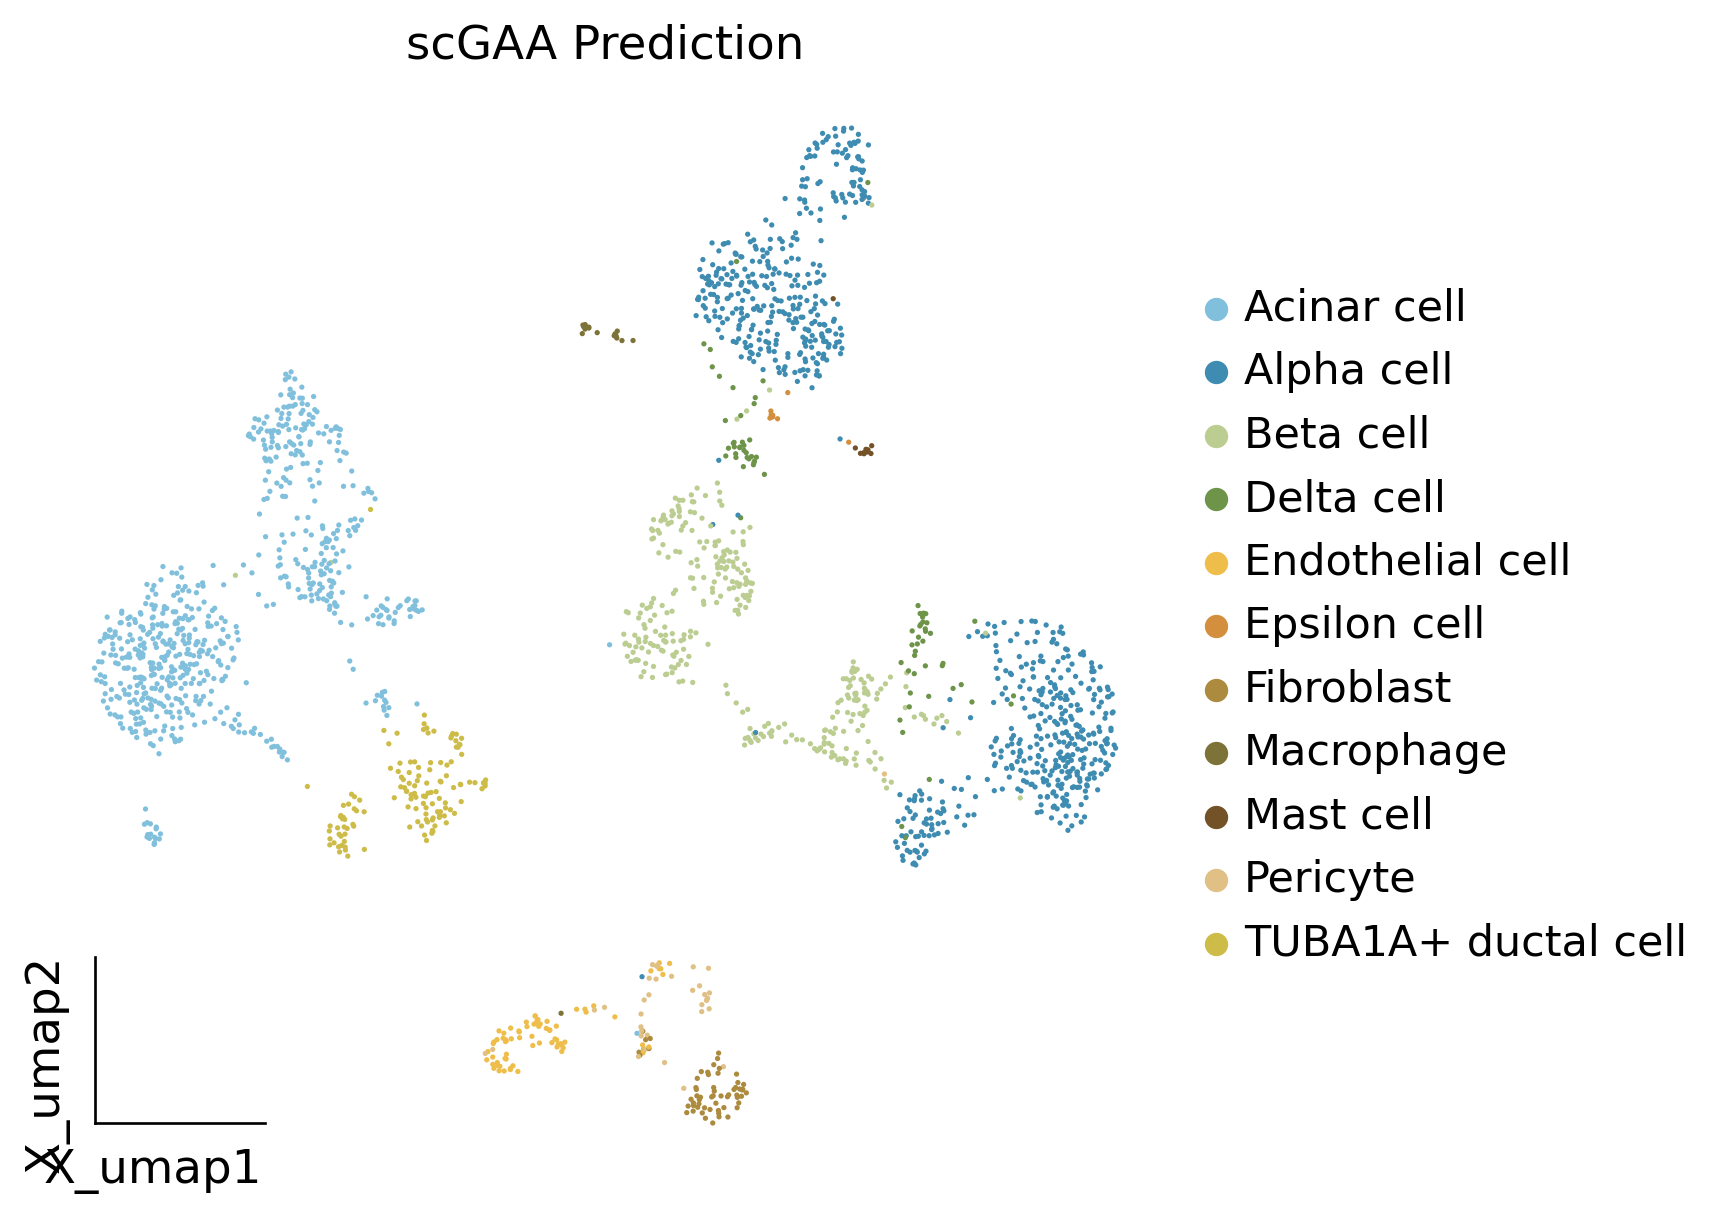

In [13]:
fig, ax = plt.subplots(figsize=(6,6))
ov.utils.embedding(test_adata,
    basis="X_umap",
    color=['Prediction'],title='scGAA Prediction',
    show=False,  
    size=10,
    frameon='small',
    palette=ov.utils.blue_color[2:4]+ov.utils.green_color[4:6]+ov.utils.orange_color[:],
    ax=ax
)

<Figure size 480x480 with 0 Axes>

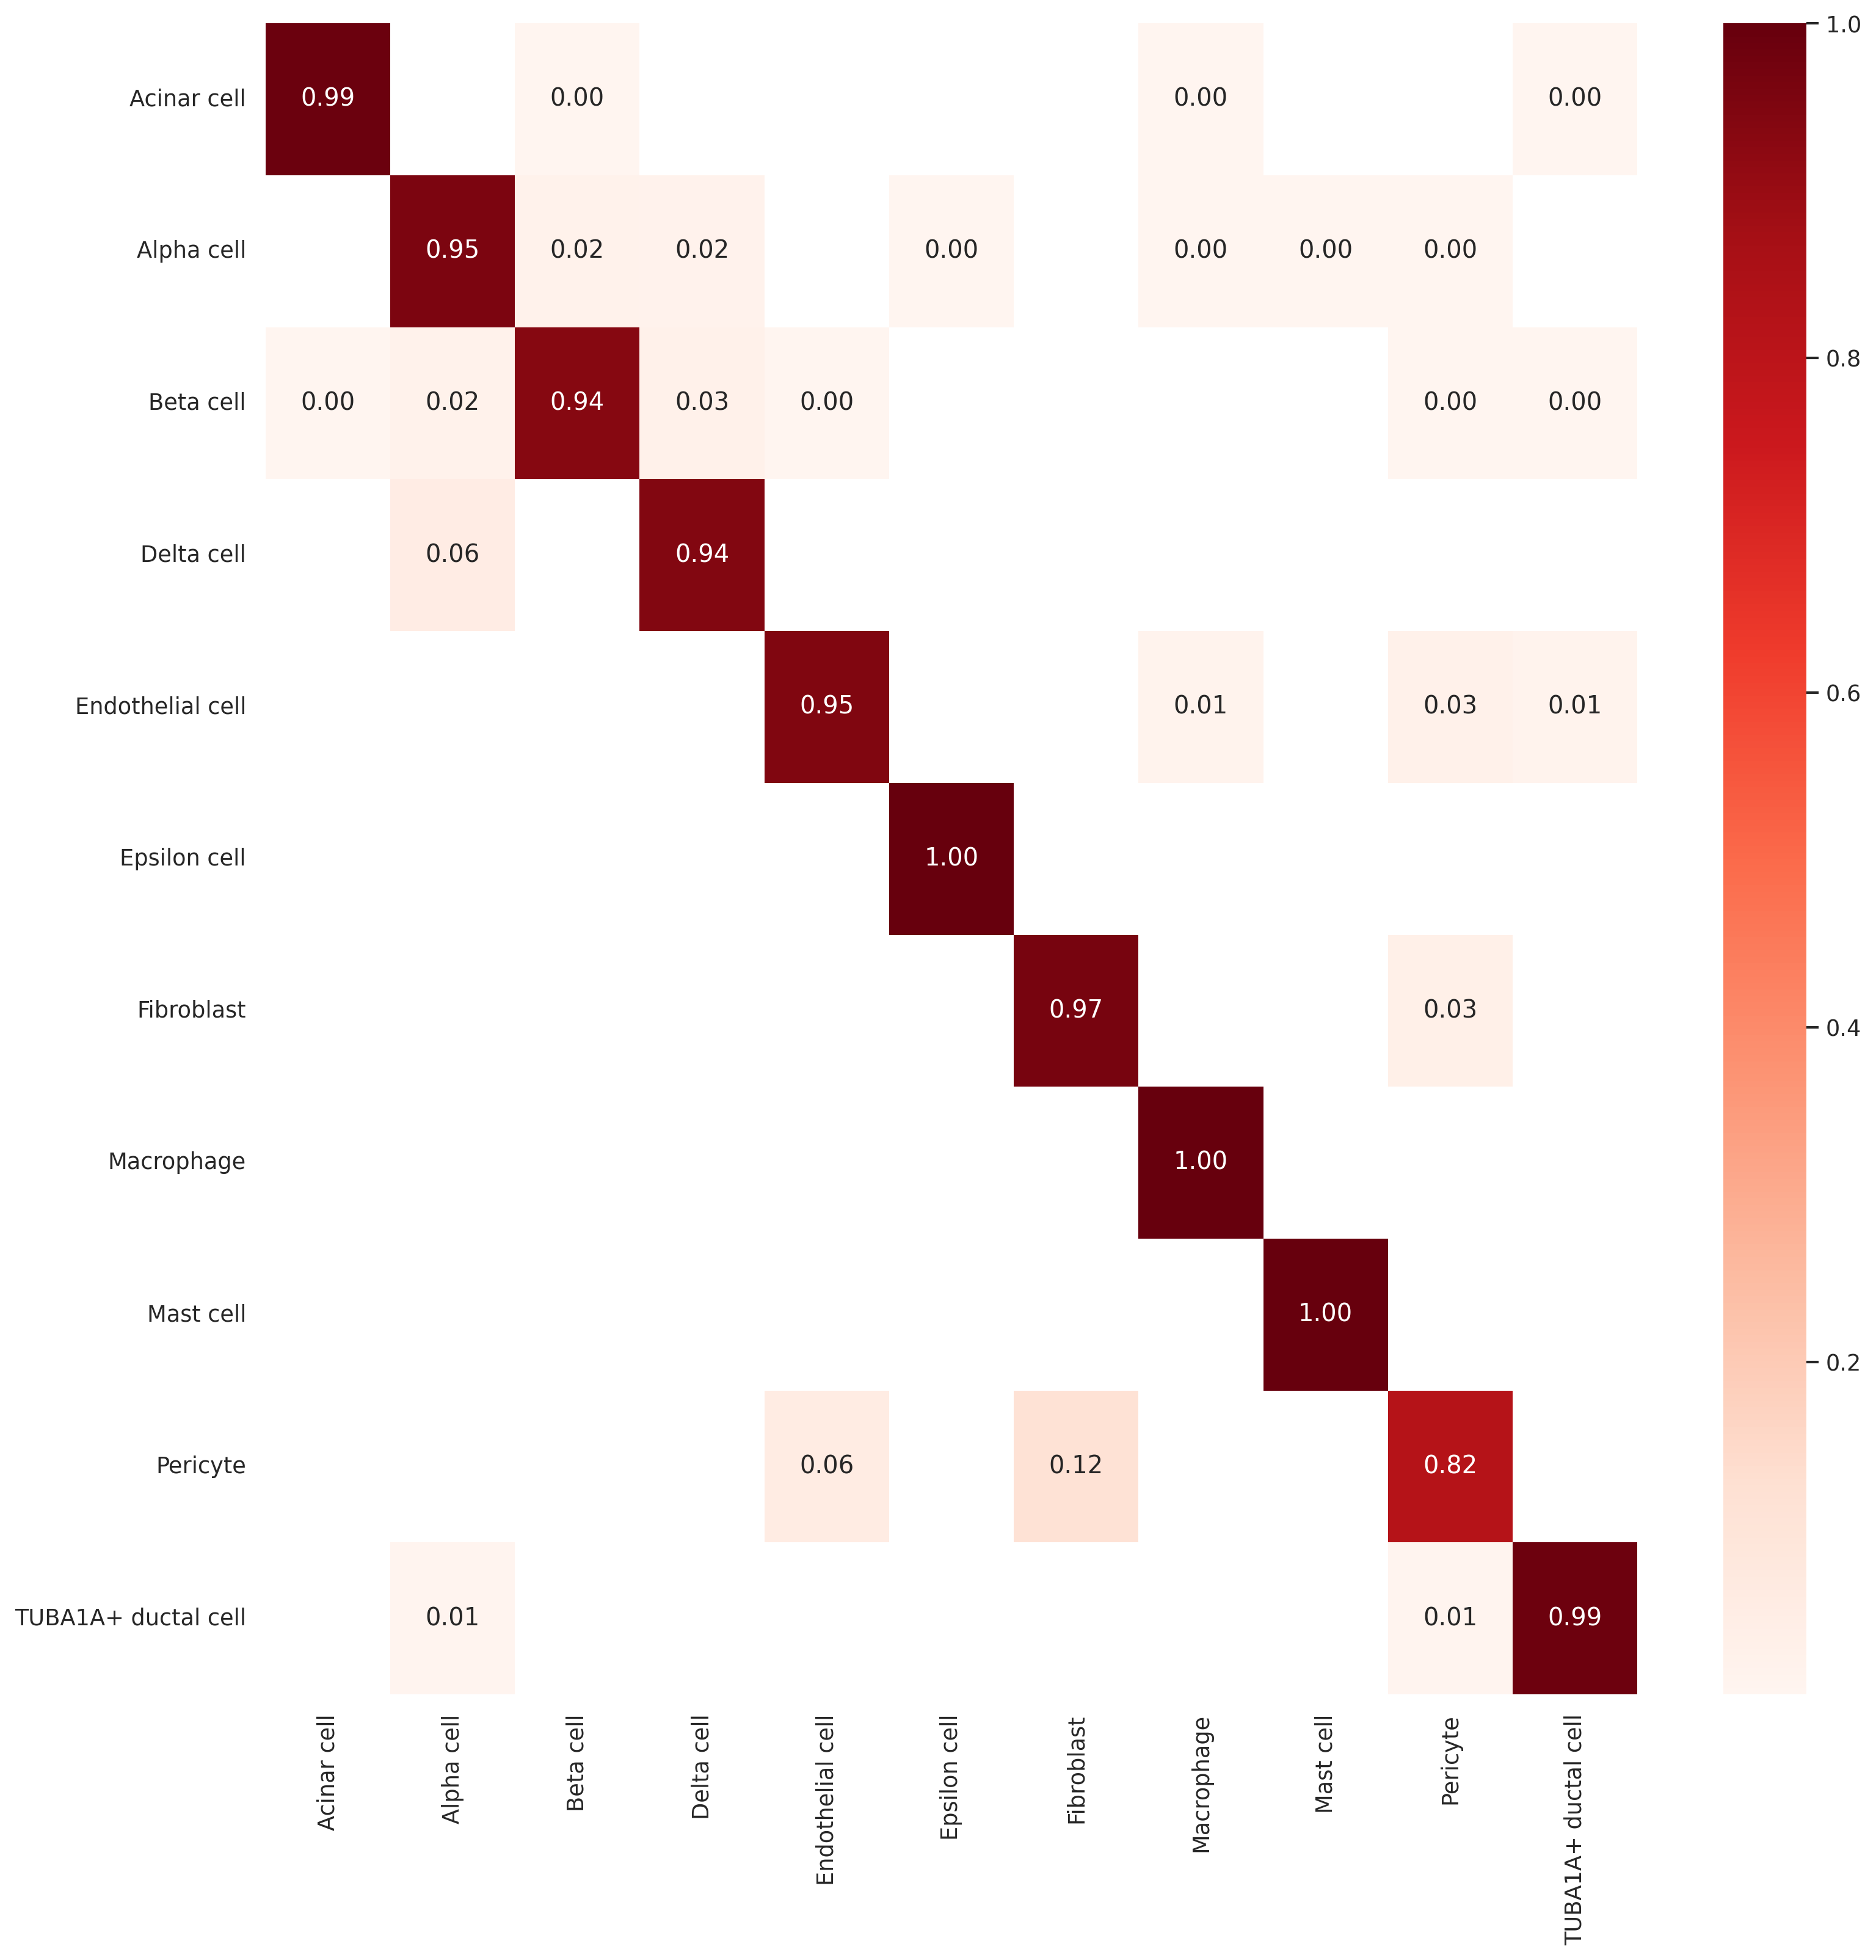

In [14]:
encoder = LabelEncoder()


actual = new_adata.obs['celltype'].values
predicted = new_adata.obs['Prediction'].values
all_labels = np.concatenate([actual, predicted])
encoder.fit(all_labels)
actual_encoded = encoder.transform(actual)
predicted_encoded = encoder.transform(predicted)


sns.set(font_scale=1) 
sns.set_style("white")
sns.despine()

matrix = confusion_matrix(actual_encoded, predicted_encoded)
matrix_normalized = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]


cell_type_labels = encoder.classes_
conf_norm_df = pd.DataFrame(matrix_normalized, index=cell_type_labels, columns=cell_type_labels)


mask = np.isclose(conf_norm_df.values, 0)


fig, ax = plt.subplots(figsize=(15, 15)) 
sns.heatmap(conf_norm_df, cmap='Reds', annot=True, fmt='.2f', mask=mask, ax=ax)

plt.show()

Test

In [16]:
adata = sc.read('data/test.h5ad')

In [17]:
adata

AnnData object with n_obs × n_vars = 10957 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'celltype', 'cell.type.score', 'sampling.weight', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'features', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    layers: 'log1p_norm'

In [18]:
model_weight_path = 'Demo_test/model-5.pth'
new_adata = scGAA.pre(adata, model_weight_path = model_weight_path,project='Demo_test')

cpu
0
10000
10957


In [29]:
adata.obs['Prediction'] = new_adata.obs['Prediction']

In [19]:
from sklearn import metrics
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(new_adata.obs['celltype'].values, new_adata.obs['Prediction'].values)

print("Accuracy: ", accuracy)
from sklearn.metrics import f1_score
f1 = f1_score(new_adata.obs['celltype'].values, new_adata.obs['Prediction'].values, average='macro')  
print(f"F1 Score: {f1}")

Accuracy:  0.9811079675093548
F1 Score: 0.9591778591530893


In [22]:
sc.pp.scale(adata, max_value=10) 
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.tsne(adata)

In [28]:
adata

AnnData object with n_obs × n_vars = 10957 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'celltype', 'cell.type.score', 'sampling.weight', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'features', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'tsne', 'Prediction_colors', 'Celltype_colors', 'celltype_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'dist

In [37]:
mycolr1 = ["#AEC7E8","#C5B0D5","#9467BD","#98DF8A","#2CA02C",
          "#F7B6D2","#E377C2","#DBDB8D","#BCBD22","#C49C94","#1F77B4"]

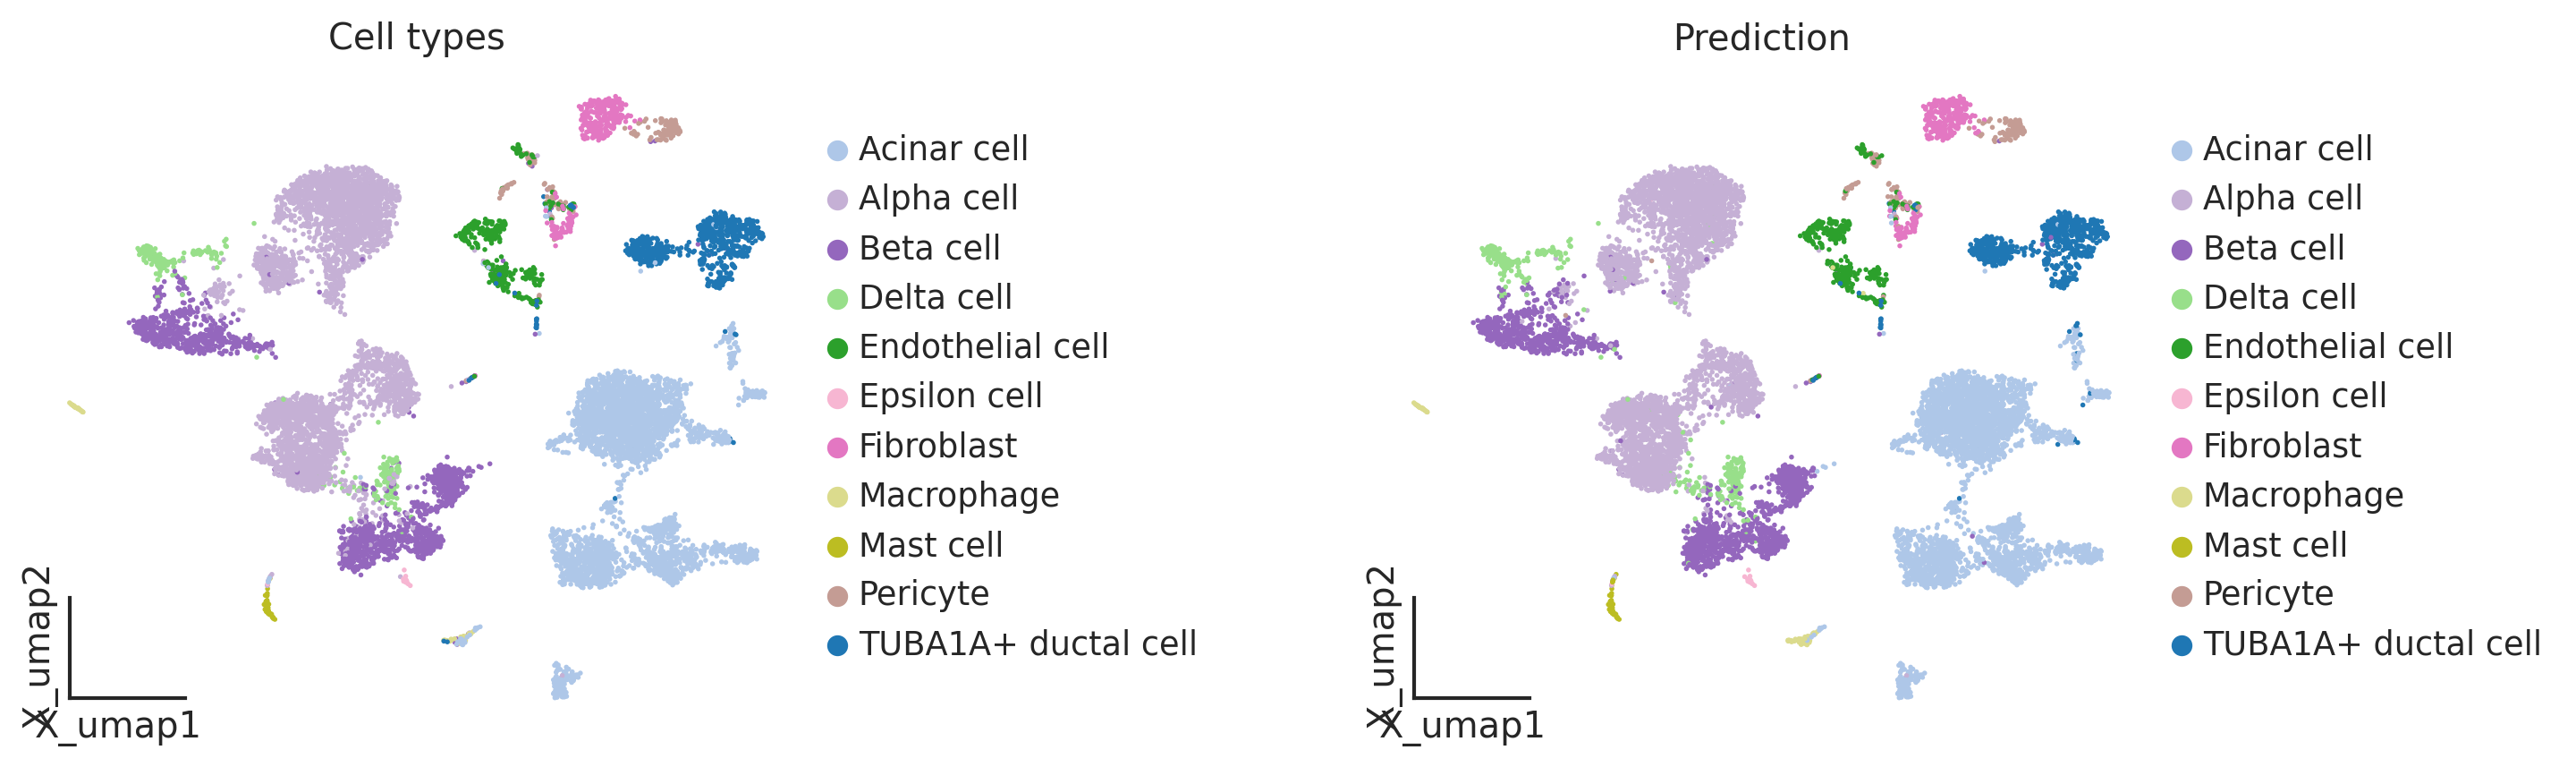

In [38]:
ov.utils.embedding(adata,
                basis='X_umap',
                color=[ "celltype","Prediction"],
                title=['Cell types','Prediction'],
                palette=mycolr1,
                wspace=0.6,
                show=True,
                frameon='small'
)

<Figure size 480x480 with 0 Axes>

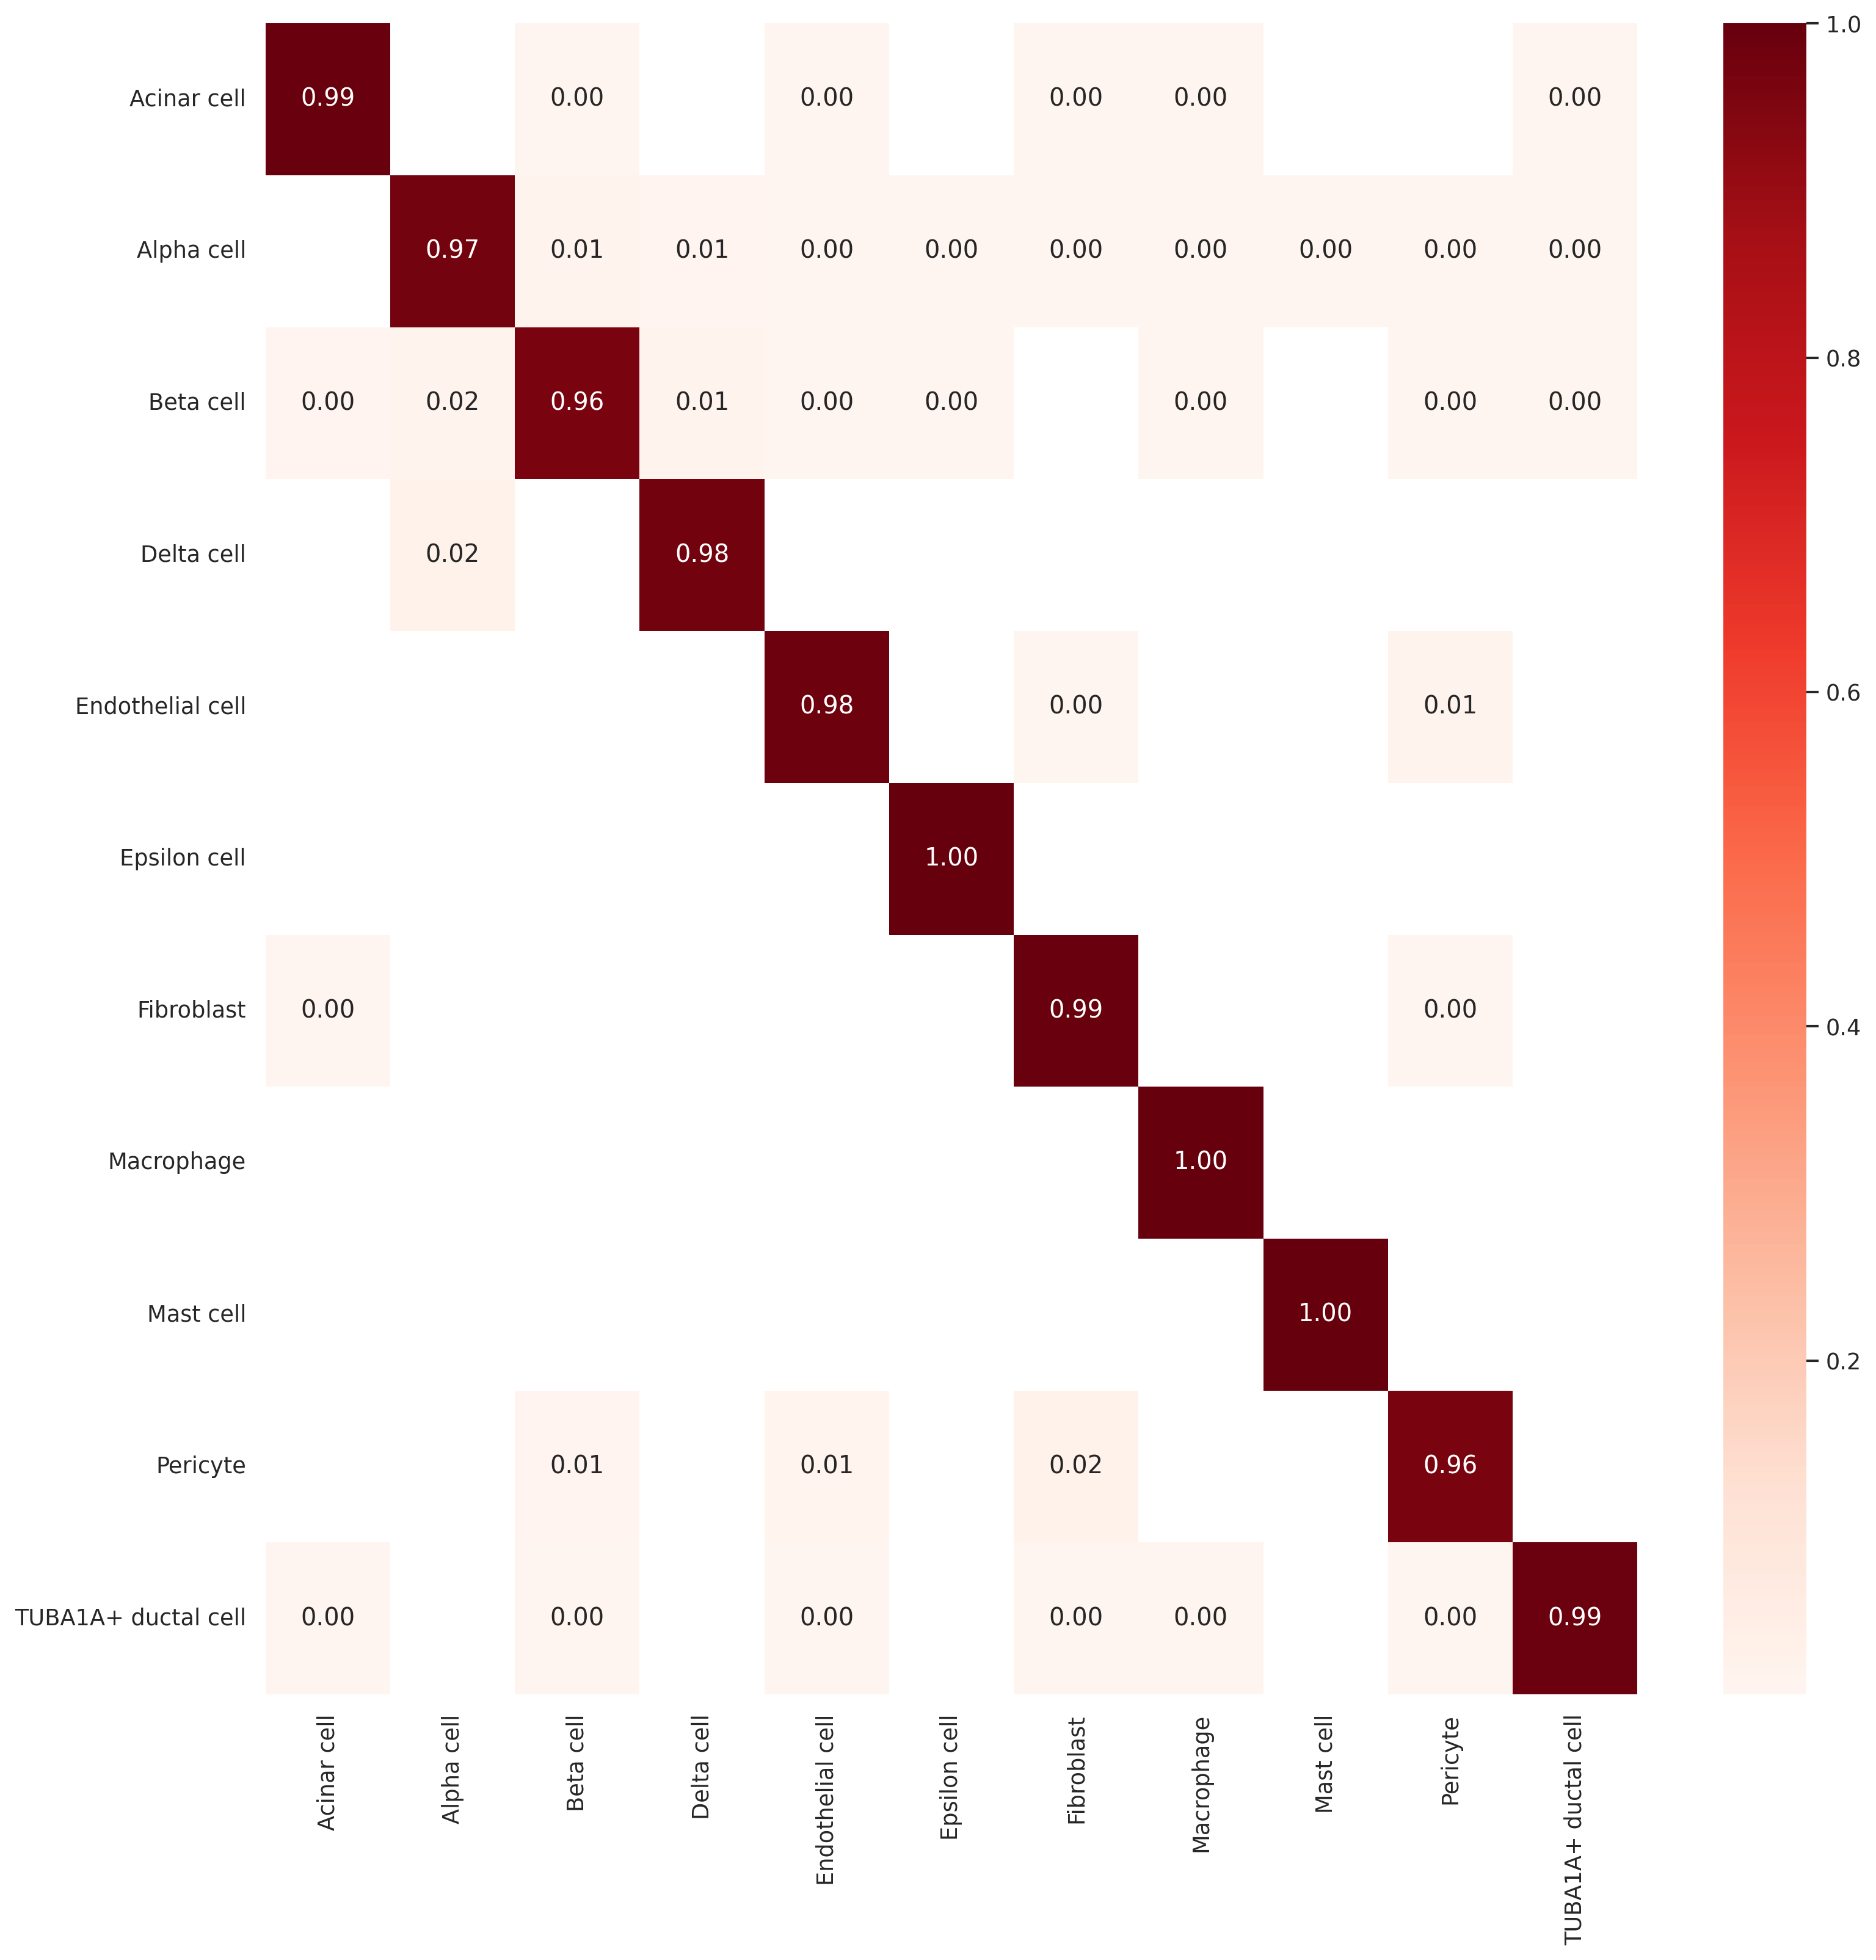

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.colors as colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


encoder = LabelEncoder()

actual = new_adata.obs['celltype'].values
predicted = new_adata.obs['Prediction'].values
all_labels = np.concatenate([actual, predicted])
encoder.fit(all_labels)
actual_encoded = encoder.transform(actual)
predicted_encoded = encoder.transform(predicted)


sns.set(font_scale=1) 
sns.set_style("white")
sns.despine()


matrix = confusion_matrix(actual_encoded, predicted_encoded)
matrix_normalized = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]


cell_type_labels = encoder.classes_
conf_norm_df = pd.DataFrame(matrix_normalized, index=cell_type_labels, columns=cell_type_labels)


mask = np.isclose(conf_norm_df.values, 0)


fig, ax = plt.subplots(figsize=(15, 15))  
sns.heatmap(conf_norm_df, cmap='Reds', annot=True, fmt='.2f', mask=mask, ax=ax)
plt.show()